# Imports

In [1]:
import pandas as pd 
import numpy as np
import model.eda as eda
from model.preprocessing import preprocess_data
from model.features import create_features
from model.baseline import train_baseline
from model.models import train_models
from model.feature_selection import analyze_features
from model.tuning import tune_hyperparams
from model.final_model import train_final_model, generate_predictions

# Paths

In [2]:
test_path=r'C:\Users\Lenovo\OneDrive\Sandbox\mfti\data\test_apps.csv'
train_path = r'C:\Users\Lenovo\OneDrive\Sandbox\mfti\data\train_apps.csv'

# Exploratory Data Analysis

############################################################
#  EXPLORATORY DATA ANALYSIS
############################################################

Loading data...


  Train: (145241, 28)
  Test:  (36311, 27)
DATA STRUCTURE OVERVIEW

Train shape: (145241, 28)
Test shape:  (36311, 27)

--- Train dtypes ---
  float64: 23 columns
  str: 3 columns
  int64: 2 columns

--- Missing values (columns with any missing in train) ---
Total columns with missings in train: 20
  overdraft_app_term_max_360              Max. overdraft app term, 360d
      Train: 139,732  ( 96.2%)   Test:  33,410  ( 92.0%)
  loan_rev_max_start_non_fin              Months to max start date (active revolving)
      Train: 132,635  ( 91.3%)   Test:  31,125  ( 85.7%)
  sum_deb_investment_90                   Investments & deposits, 90d
      Train: 128,697  ( 88.6%)   Test:  28,116  ( 77.4%)
  loan_rev_min_start_fin                  Months to min start date (closed revolving)
      Train: 124,706  ( 85.9%)   Test:  26,916  ( 74.1%)
  days_from_authperson_registration       Days since manager registration
      Train:  78,473  ( 54.0%)   Test:  15,612  ( 43.0%)
  sum_deb_ul_30            

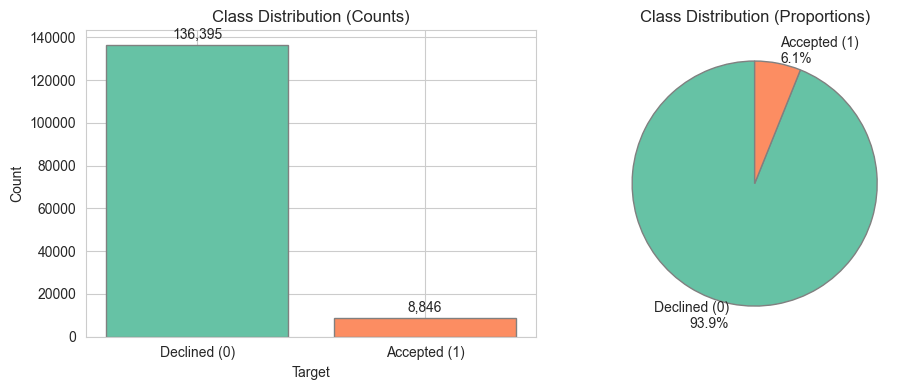

NUMERICAL FEATURE ANALYSIS

--- Summary statistics ---
                                                                             mean     std       min       p1      p5     p50     p95     p99      max    skew  kurtosis  missing%  outliers
loan_amount_last  (Requested loan amount)                                  0.0079  1.5663   -5.6170  -3.4315 -2.8085  0.0000  2.1854  2.8085   3.0309 -0.3120   -0.6932    0.0000         0
overdraft_limit_min  (Min. overdraft limit (pre-scoring))                 -0.0795  2.8599   -8.3789  -4.4711 -4.1682 -0.3800  5.0654  5.2118   6.1315  0.2153   -1.0221    0.0000         0
overdraft_limit_max  (Max. overdraft limit (pre-scoring))                 -0.1522  2.2722   -6.7385  -3.6558 -3.4169 -0.3665  3.9057  3.9825   4.7080  0.1984   -1.0418    0.0000         0
offered_rate  (Offered interest rate)                                      0.4517 17.0851 -161.1177 -50.5711 -3.5488 -0.1774  8.1624 53.0553 165.0214  0.2592   63.4062    0.0000      3055
cb_ra

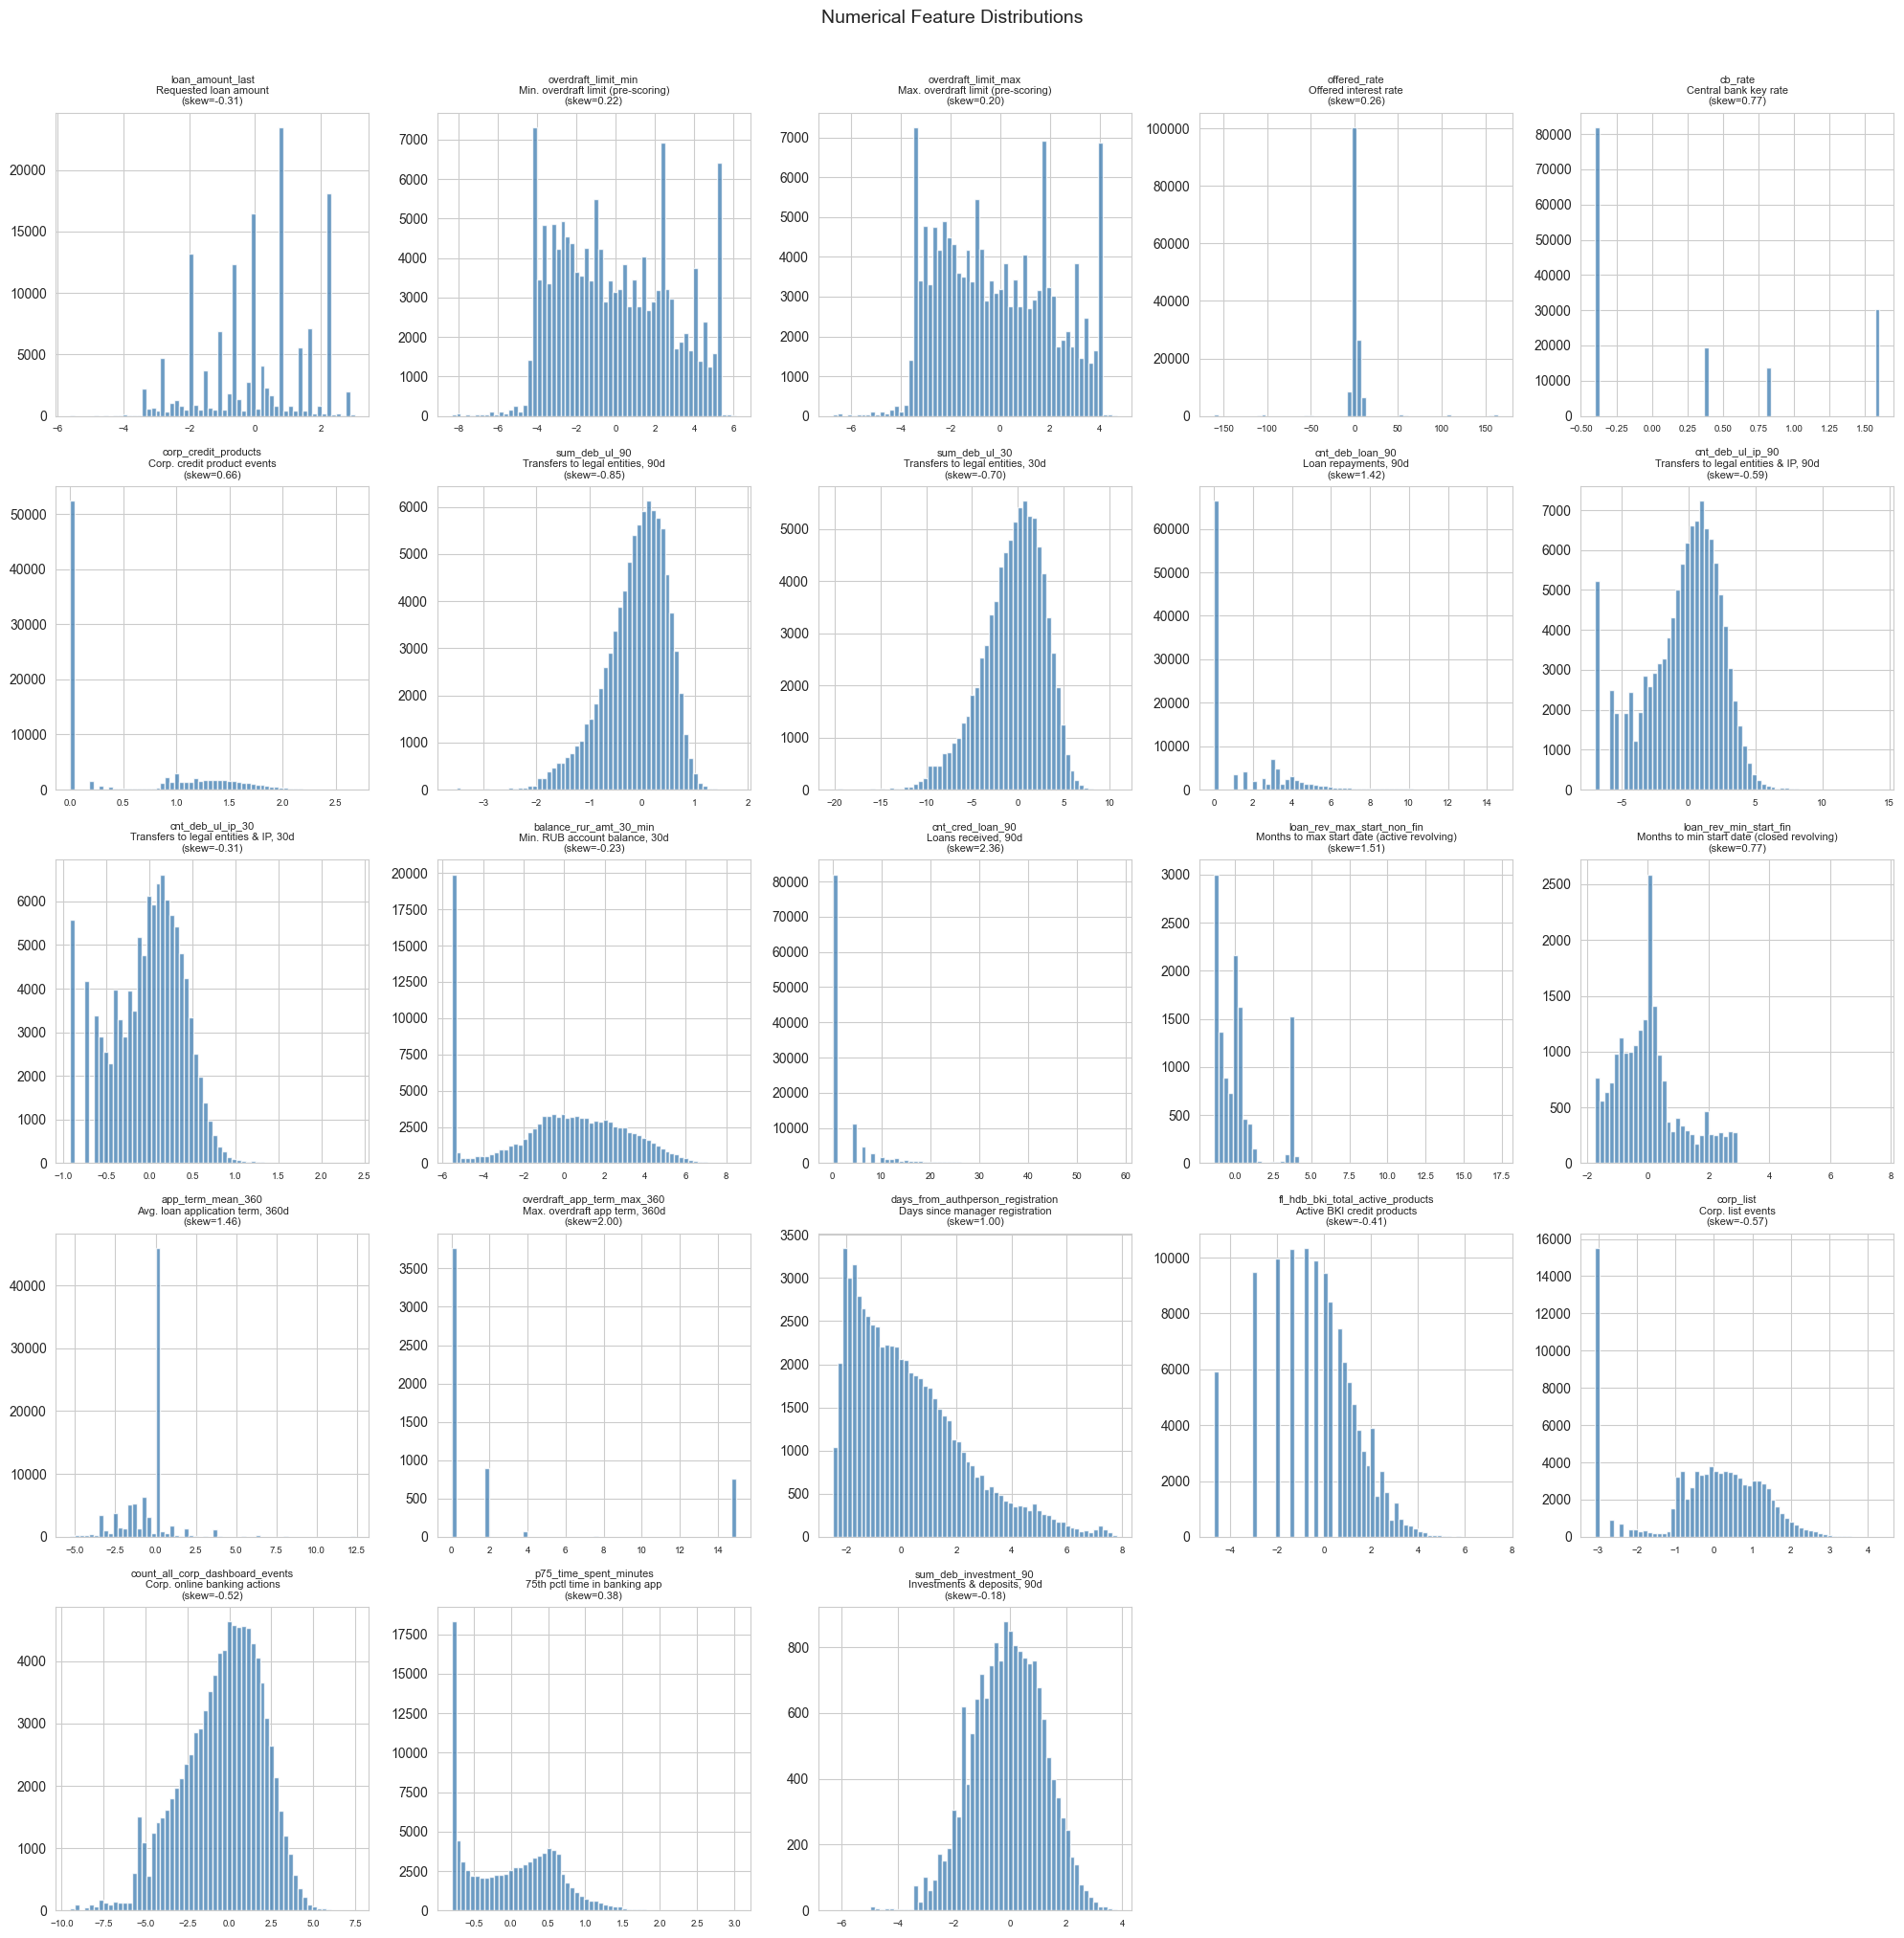

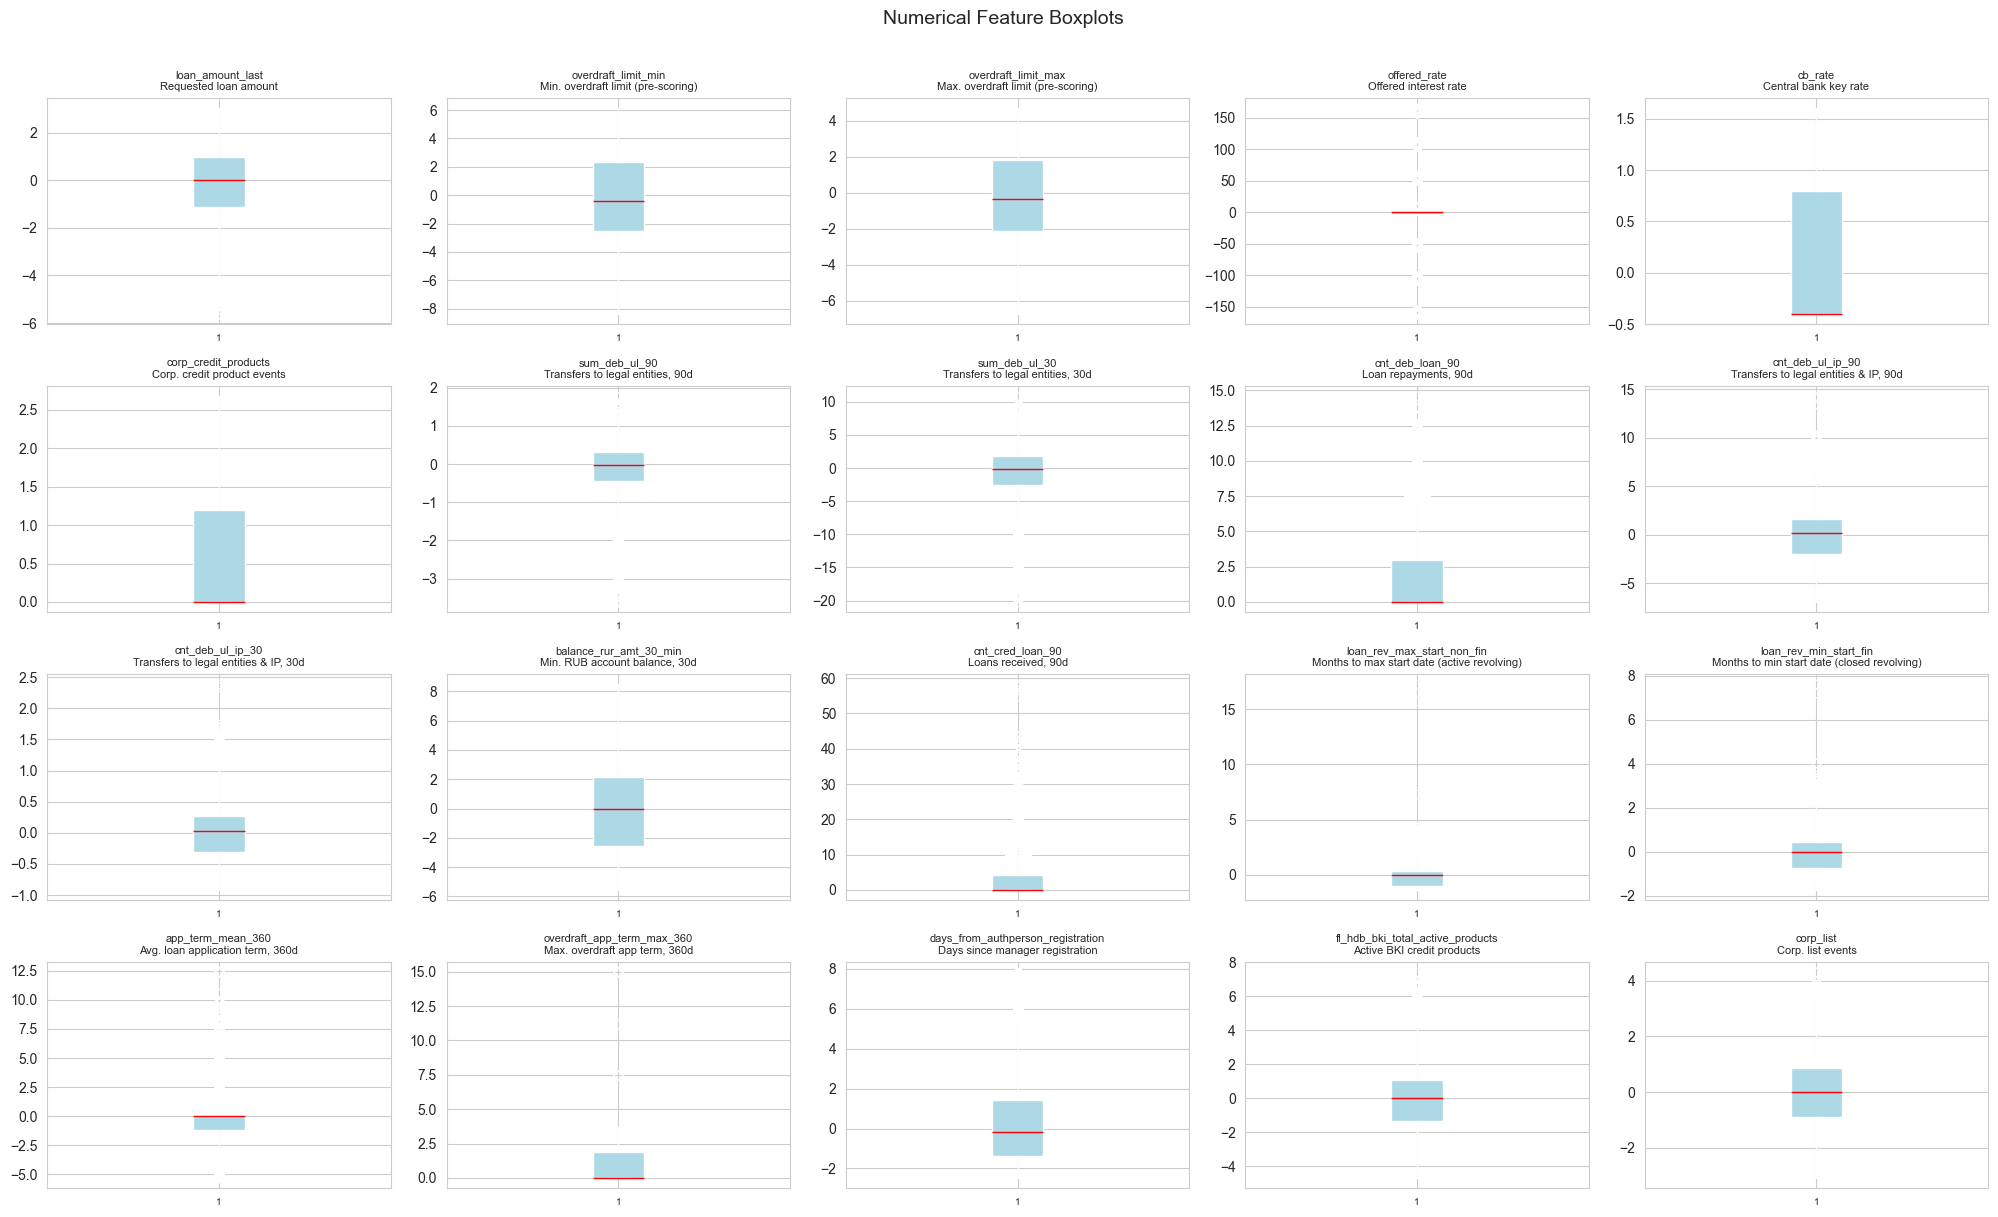

CATEGORICAL VARIABLE ANALYSIS

--- decision_day  (Decision date) ---
  Unique values: 485
              count  proportion  target_rate
decision_day                                
2024-05-13     1036      0.0071       0.0434
2024-05-20      977      0.0067       0.0450
2024-04-15      972      0.0067       0.0432
2024-05-06      945      0.0065       0.0434
2024-05-07      939      0.0065       0.0522
2024-04-22      939      0.0065       0.0277
2024-05-28      935      0.0064       0.0353
2024-05-21      920      0.0063       0.0326
2024-05-27      917      0.0063       0.0491
2024-05-15      915      0.0063       0.0426
2024-05-22      907      0.0062       0.0375
2024-05-14      902      0.0062       0.0477
2024-05-02      860      0.0059       0.0488
2024-04-18      849      0.0058       0.0389
2024-04-16      848      0.0058       0.0307
  ... and 470 more categories


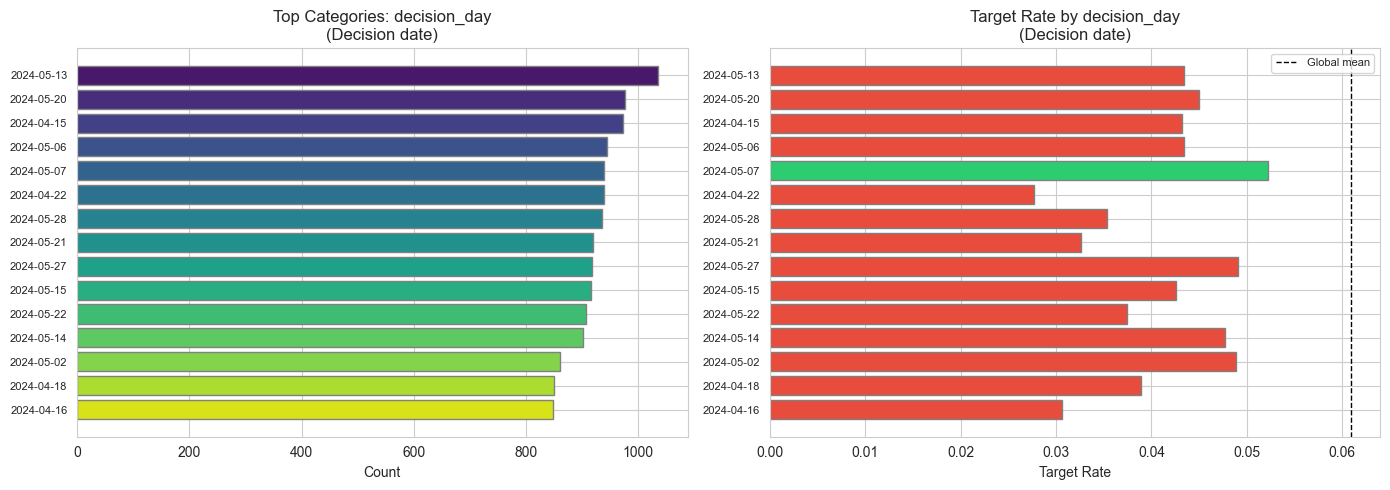


--- db_group_last  (Last credit product type) ---
  Unique values: 9
               count  proportion  target_rate
db_group_last                                
NaN            55883      0.3848       0.0525
inn_scoring    54098      0.3725       0.0615
bk             11833      0.0815       0.0472
zalog_light     8832      0.0608       0.0497
vkl             5370      0.0370       0.0723
ebg             3872      0.0267       0.0780
overdraft       2112      0.0145       0.3674
zalog_bk        1337      0.0092       0.0389
cc              1048      0.0072       0.0391
lombard          856      0.0059       0.0339


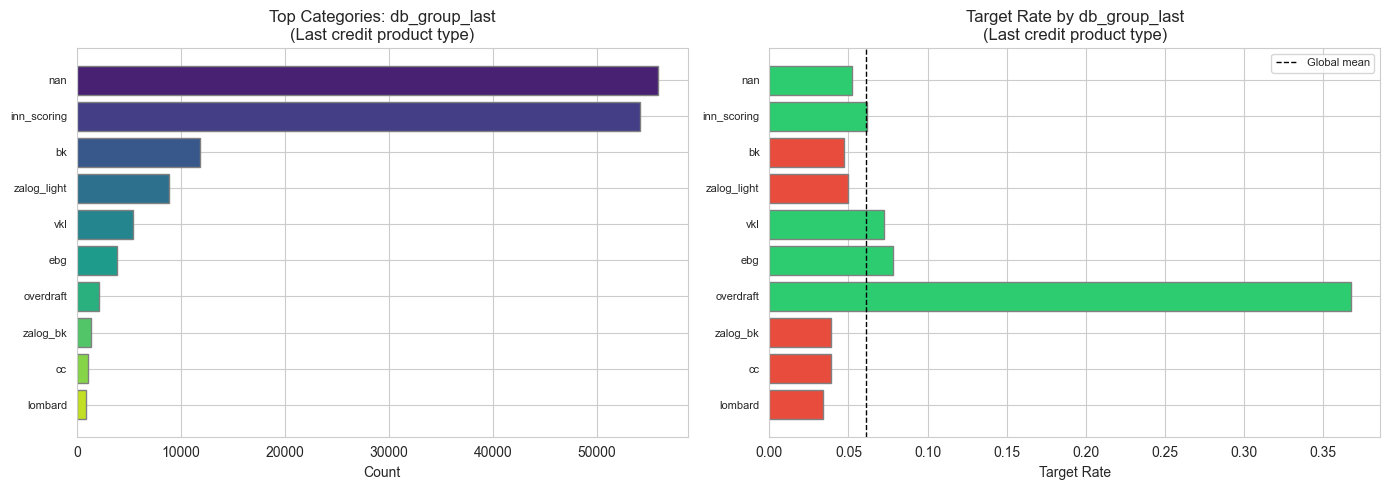


--- fl_adminarea  (Client region) ---
  Unique values: 83
                                  count  proportion  target_rate
fl_adminarea                                                    
NaN                               43310      0.2982       0.0436
г. Москва                         16576      0.1141       0.0688
Московская область                 8047      0.0554       0.0697
г. Санкт - Петербург               7306      0.0503       0.0775
Краснодарский край                 5431      0.0374       0.0661
Свердловская область               5036      0.0347       0.0925
Новосибирская область              3998      0.0275       0.0978
Республика Татарстан (Татарстан)   3423      0.0236       0.1008
Челябинская область                3154      0.0217       0.0650
Ростовская область                 2853      0.0196       0.0424
Самарская область                  2693      0.0185       0.0598
Республика Башкортостан            2606      0.0179       0.0691
Тюменская область              

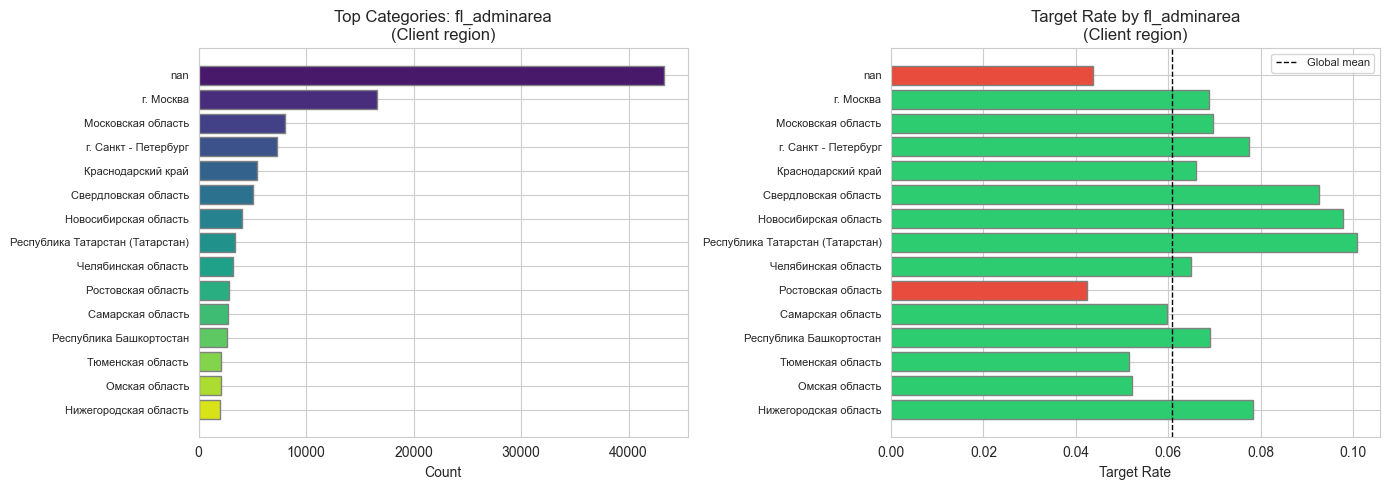

CORRELATION ANALYSIS WITH TARGET

--- Point-biserial correlation (numeric vs target) ---
                              feature                                  description  point_biserial_r  p_value
13         loan_rev_max_start_non_fin  Months to max start date (active revolving)          0.322518 0.000000
12                   cnt_cred_loan_90                          Loans received, 90d          0.206632 0.000000
8                     cnt_deb_loan_90                         Loan repayments, 90d          0.176924 0.000000
16         overdraft_app_term_max_360                Max. overdraft app term, 360d         -0.139311 0.000000
9                    cnt_deb_ul_ip_90        Transfers to legal entities & IP, 90d          0.131116 0.000000
10                   cnt_deb_ul_ip_30        Transfers to legal entities & IP, 30d          0.128847 0.000000
14             loan_rev_min_start_fin  Months to min start date (closed revolving)          0.127418 0.000000
15                  app_term_me

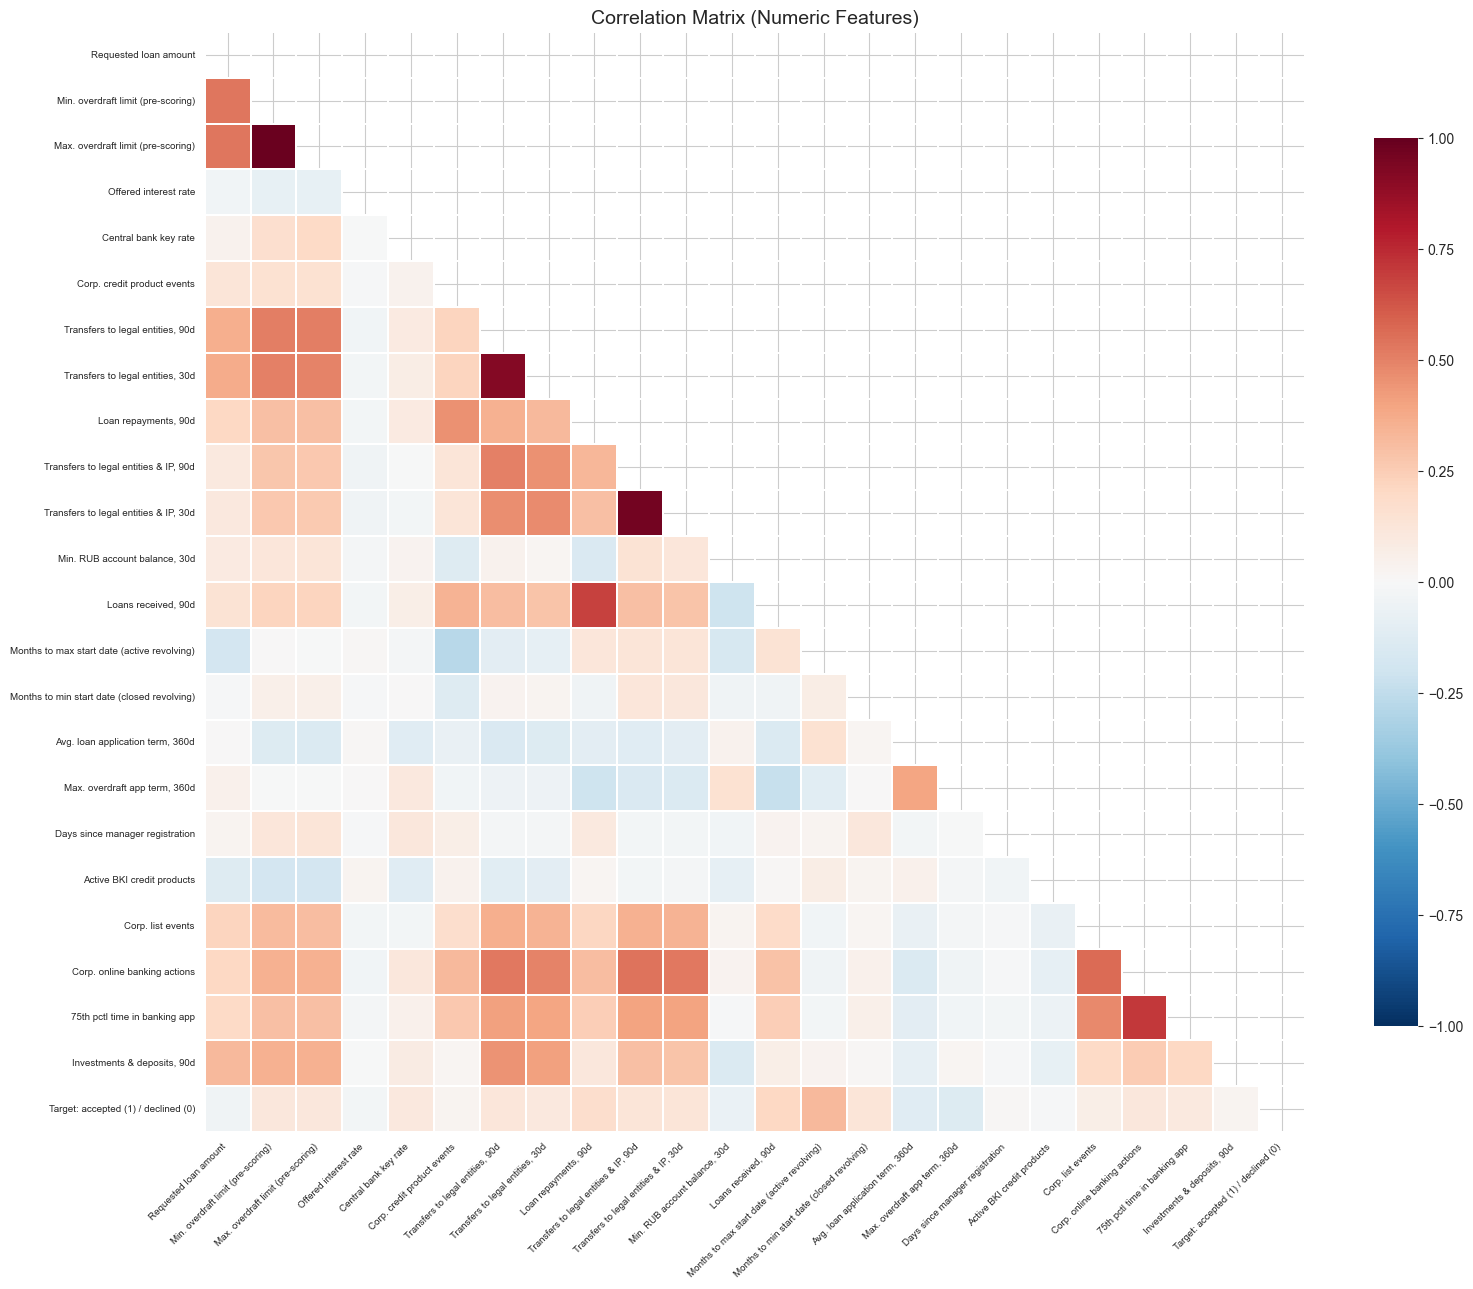

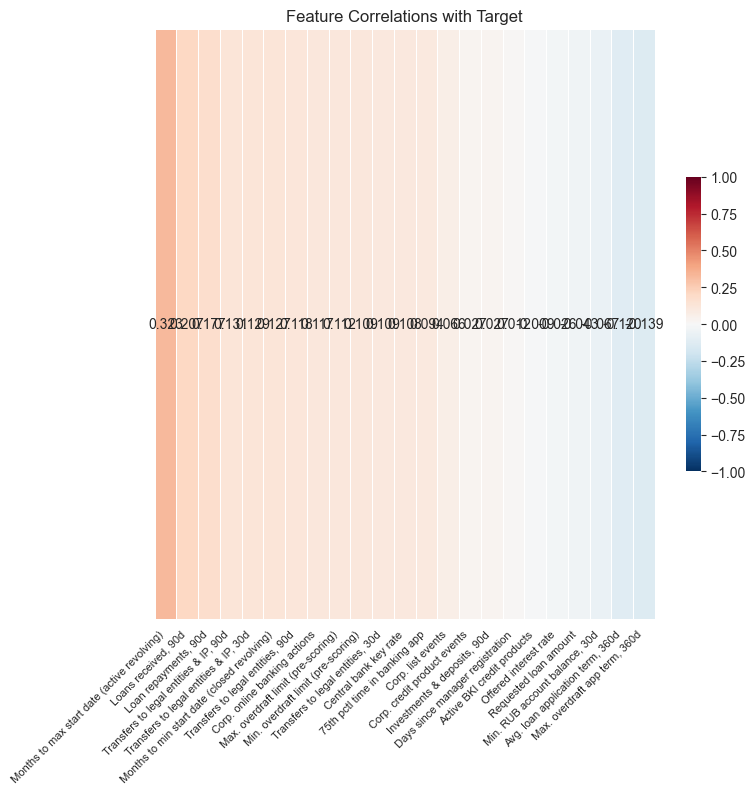

In [3]:
eda_results = eda.run_eda(train_path, test_path)

# Preprocessing & Feature selection

In [4]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

y_train = train["target_value"]  # save target before preprocessing drops it

X_train, X_test, prep = preprocess_data(train, test)
X_train_aug, X_test_aug, feat_meta = create_features(X_train, X_test)

PREPROCESSING

Fitting preprocessor on train...
  Applying 5-fold OOF target encoding for 2 categorical column(s): ['db_group_last', 'fl_adminarea']
  X_train shape: (145241, 29)

Transforming test...
  X_test shape:  (36311, 29)

Features (29 total):
  ['app_term_mean_360', 'balance_rur_amt_30_min', 'cb_rate', 'cnt_cred_loan_90', 'cnt_deb_loan_90', 'cnt_deb_ul_ip_30', 'cnt_deb_ul_ip_90', 'corp_credit_products', 'corp_list', 'count_all_corp_dashboard_events', 'days_from_authperson_registration', 'db_group_last_te', 'fl_adminarea_te', 'fl_hdb_bki_total_active_products', 'loan_amount_last', 'loan_rev_max_start_non_fin', 'loan_rev_max_start_non_fin_isnan', 'loan_rev_min_start_fin', 'loan_rev_min_start_fin_isnan', 'offered_rate', 'overdraft_app_term_max_360', 'overdraft_app_term_max_360_isnan', 'overdraft_limit_max', 'overdraft_limit_min', 'p75_time_spent_minutes', 'sum_deb_investment_90', 'sum_deb_investment_90_isnan', 'sum_deb_ul_30', 'sum_deb_ul_90']
FEATURE ENGINEERING
  log_balance: s

# Baseline model (logistic regression)

BASELINE MODEL — Logistic Regression

  Samples:       145,241
  Positive:      8,846  (6.09%)
  Negative:      136,395  (93.91%)
  Features:      38
  CV folds:      5
  Class weight:  balanced

   Fold   ROC-AUC      Gini        F1      Prec    Recall  Threshold
  -----  --------  --------  --------  --------  --------  ---------
      1    0.8036    0.6073    0.3550    0.4090    0.3136     0.8118
      2    0.8056    0.6111    0.3603    0.3827    0.3403     0.7920
      3    0.8090    0.6179    0.3509    0.3945    0.3160     0.8019
      4    0.8041    0.6081    0.3442    0.3740    0.3188     0.7920
      5    0.7929    0.5859    0.3404    0.3166    0.3680     0.7425

  ── Mean ────────────────────────────────────────────────
  ROC-AUC:  0.8030  ± 0.0060
  Gini:     0.6061  ± 0.0120
  F1:       0.3502  ± 0.0080
  Precision:0.3754  ± 0.0354
  Recall:   0.3313  ± 0.0231

  Optimal threshold (OOF, by F1): 0.7920  (F1=0.3487, Prec=0.3753, Recall=0.3257)

  Top 10 coefficients:
    −    

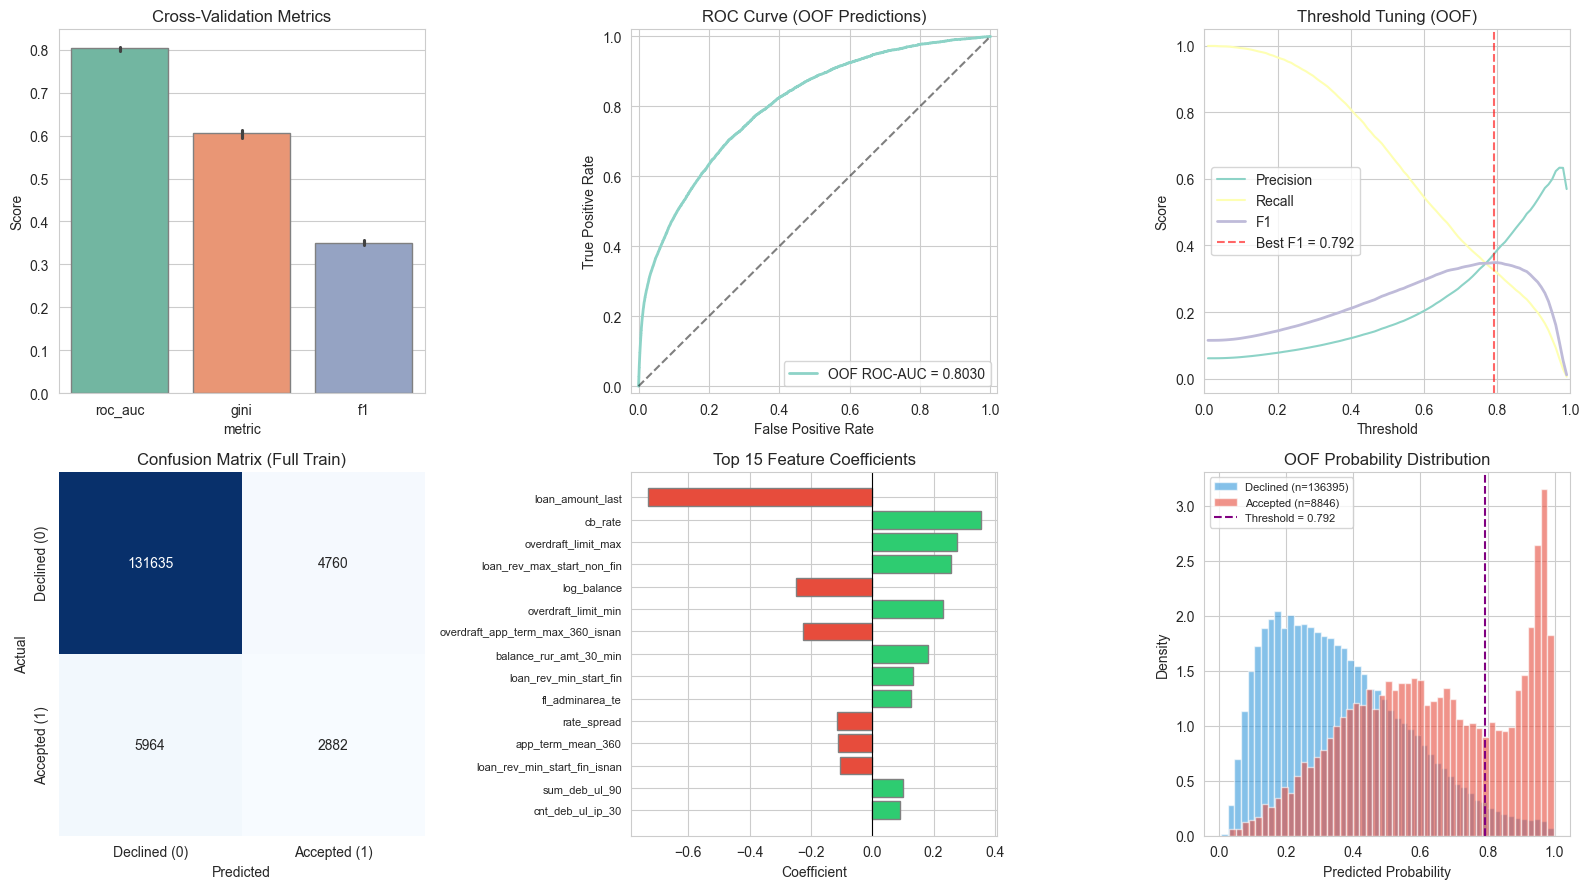


  ── Final model (full train) ──
  ROC-AUC:  0.8041
  F1:       0.3496
  Precision:0.3771
  Recall:   0.3258


In [5]:
baseline_results = train_baseline(X_train_aug, y_train, plot=True)

# Main models training

MAIN MODELS — Comparison

  Samples:   145,241
  Positive:  8,846 (6.09%)
  Features:  38
  CV folds:  5

  >>> LightGBM
      ROC-AUC: 0.8156 ± 0.0057   Gini: 0.6312   F1: 0.3696   Prec: 0.3739   Recall: 0.3698

  >>> XGBoost
      ROC-AUC: 0.8197 ± 0.0063   Gini: 0.6394   F1: 0.3694   Prec: 0.3602   Recall: 0.3830

  >>> CatBoost
      ROC-AUC: 0.8284 ± 0.0053   Gini: 0.6567   F1: 0.3815   Prec: 0.4017   Recall: 0.3657

  >>> RandomForest
      ROC-AUC: 0.8254 ± 0.0062   Gini: 0.6507   F1: 0.3740   Prec: 0.3929   Recall: 0.3572

  ────────────────────────────────────────────────────────────
  COMPARISON TABLE
  ────────────────────────────────────────────────────────────
       Model ROC-AUC   Gini     F1 Precision Recall
    LightGBM  0.8156 0.6312 0.3696    0.3739 0.3698
     XGBoost  0.8197 0.6394 0.3694    0.3602 0.3830
    CatBoost  0.8284 0.6567 0.3815    0.4017 0.3657
RandomForest  0.8254 0.6507 0.3740    0.3929 0.3572
  ────────────────────────────────────────────────────────

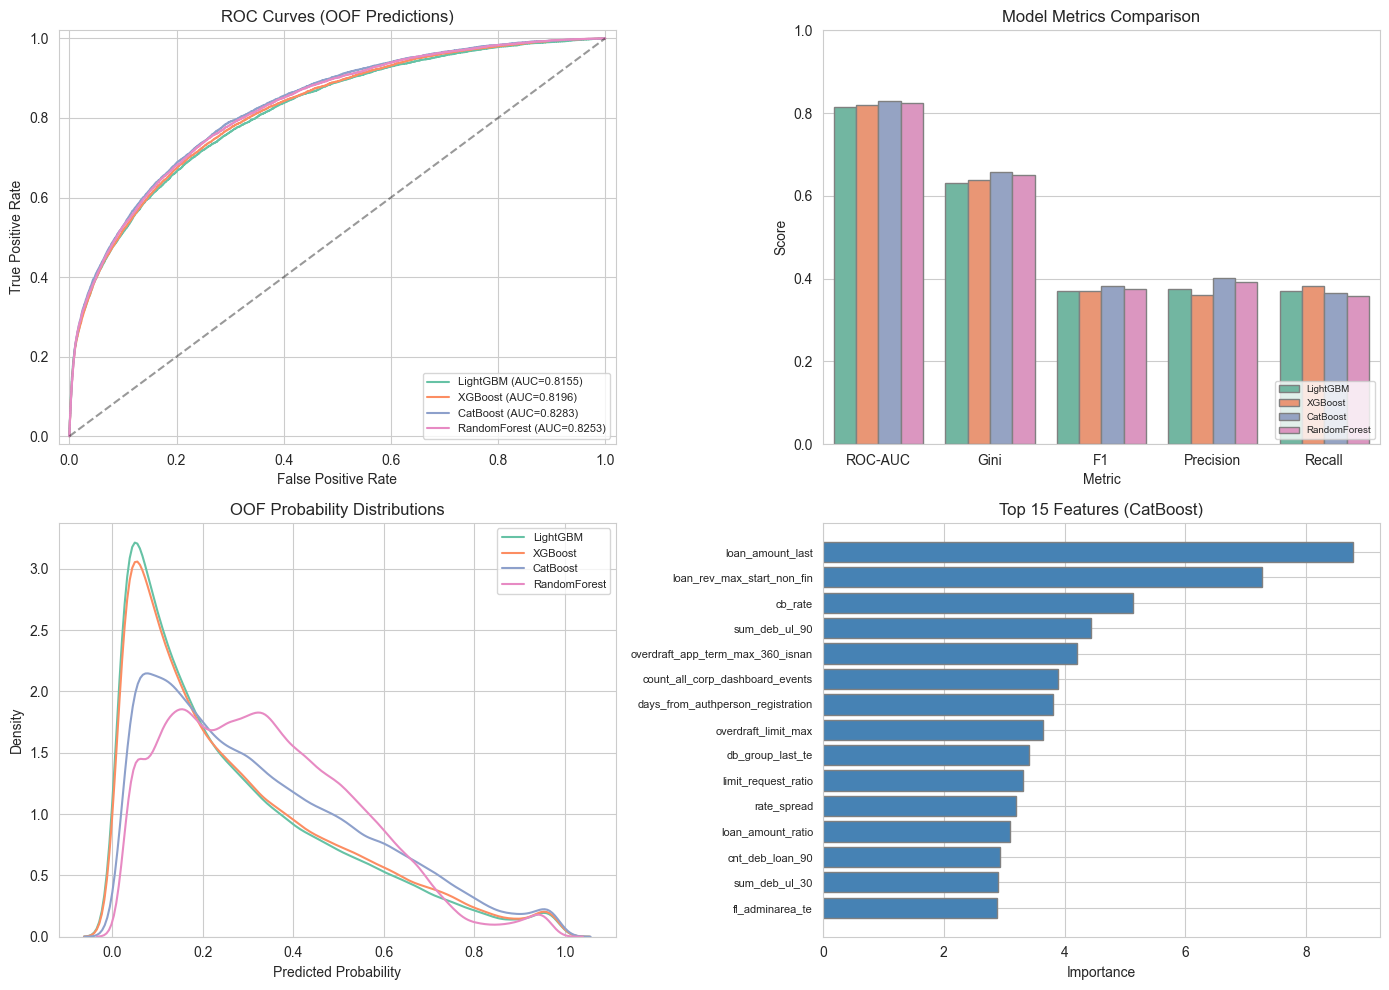

In [6]:
model_results = train_models(X_train_aug, y_train, plot=True)

## Feature Selection

FEATURE SELECTION

  Analysing model: CatBoost
  Features:        38
  Samples:         145,241

  ── Gain-based importance ──
    0.0878  loan_amount_last
    0.0727  loan_rev_max_start_non_fin
    0.0513  cb_rate
    0.0445  sum_deb_ul_90
    0.0421  overdraft_app_term_max_360_isnan
    0.0388  count_all_corp_dashboard_events
    0.0381  days_from_authperson_registration
    0.0365  overdraft_limit_max
    0.0342  db_group_last_te
    0.0332  limit_request_ratio

  ── Permutation importance ──
    0.038676  ± 0.004806  loan_amount_last
    0.021874  ± 0.003424  cb_rate
    0.013966  ± 0.001617  sum_deb_ul_90
    0.011483  ± 0.001326  count_all_corp_dashboard_events
    0.010969  ± 0.001276  days_from_authperson_registration
    0.008913  ± 0.001715  db_group_last_te
    0.008820  ± 0.001131  app_term_mean_360
    0.008257  ± 0.000686  loan_rev_max_start_non_fin
    0.007903  ± 0.002419  rate_spread
    0.007638  ± 0.002144  overdraft_limit_max

  ── SHAP analysis (sample=500) ──
    

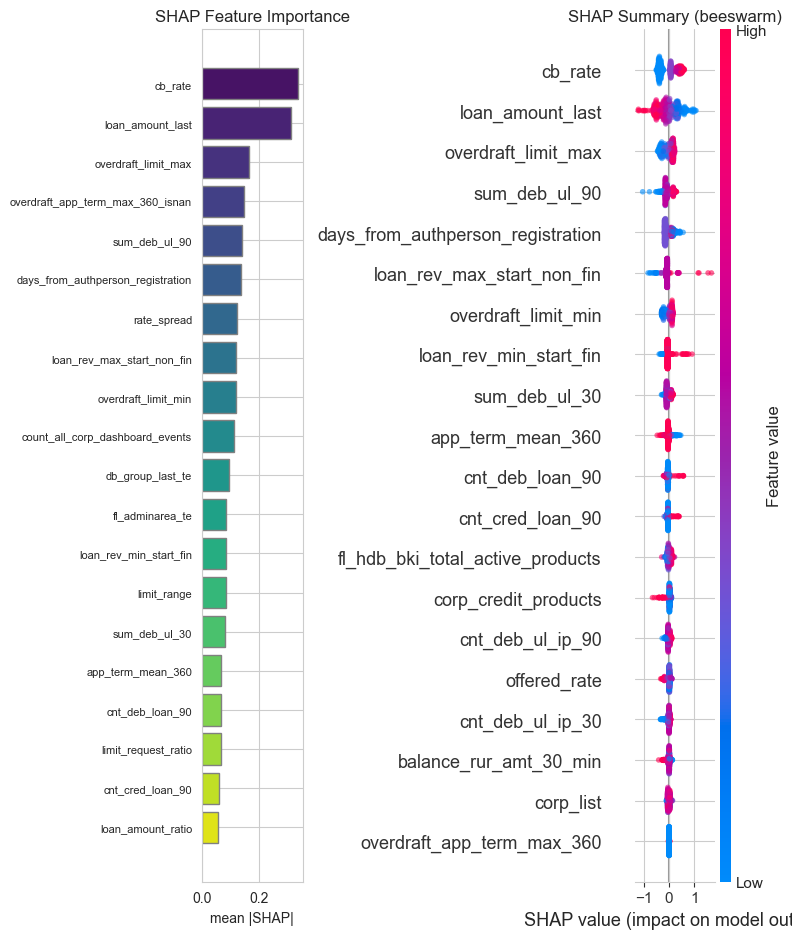

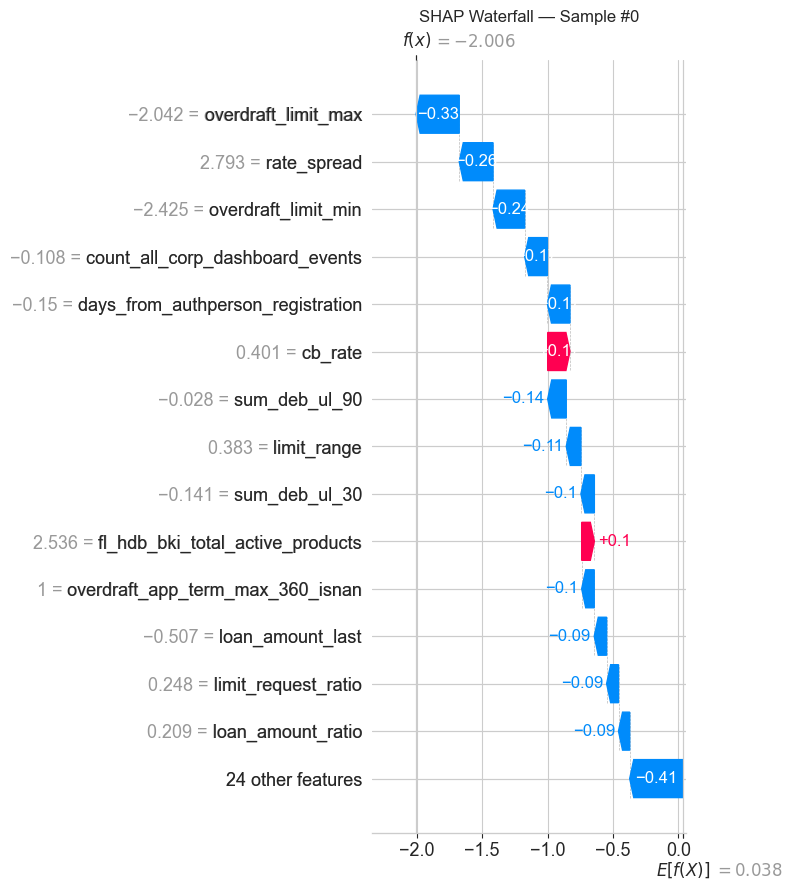


  ── Combined ranking (top 15) ──
                              feature  gain_importance  perm_importance_mean  shap_importance  avg_importance
0                    loan_amount_last         0.087812              0.038676         0.313625        0.146704
1                             cb_rate         0.051253              0.021874         0.335489        0.136205
2                 overdraft_limit_max         0.036505              0.007638         0.164265        0.069469
3          loan_rev_max_start_non_fin         0.072659              0.008257         0.118995        0.066637
4                       sum_deb_ul_90         0.044452              0.013966         0.139409        0.065942
5    overdraft_app_term_max_360_isnan         0.042054              0.001873         0.148253        0.064060
6   days_from_authperson_registration         0.038107              0.010969         0.137213        0.062096
7                         rate_spread         0.032036              0.007903         

In [7]:
analysis = analyze_features(model_results, X_train_aug, y_train, plot=True)
selected = analysis["selected_features"]
print(f"Selected {len(selected)} / {len(X_train_aug.columns)} features")

## Hyperparameter Tuning

[I 2026-06-09 00:06:32,200] A new study created in memory with name: no-name-6d2948c7-3378-4b5c-8c2a-880150b569f4


HYPERPARAMETER TUNING — LightGBM

  Model:      LightGBM
  Trials:     30
  CV folds:   3
  Features:   38
  Samples:    145,241

  Running 30 trials...
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[16]	valid_0's auc: 0.792553	valid_0's binary_logloss: 0.673169
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[13]	valid_0's auc: 0.799549	valid_0's binary_logloss: 0.676549
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's auc: 0.799457	valid_0's binary_logloss: 0.67899
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[350]	valid_0's auc: 0.814612	valid_0's binary_logloss: 0.517897
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[350]	valid_0's auc: 0.821022	valid_0's binary_logloss: 0.516481
Training until valid

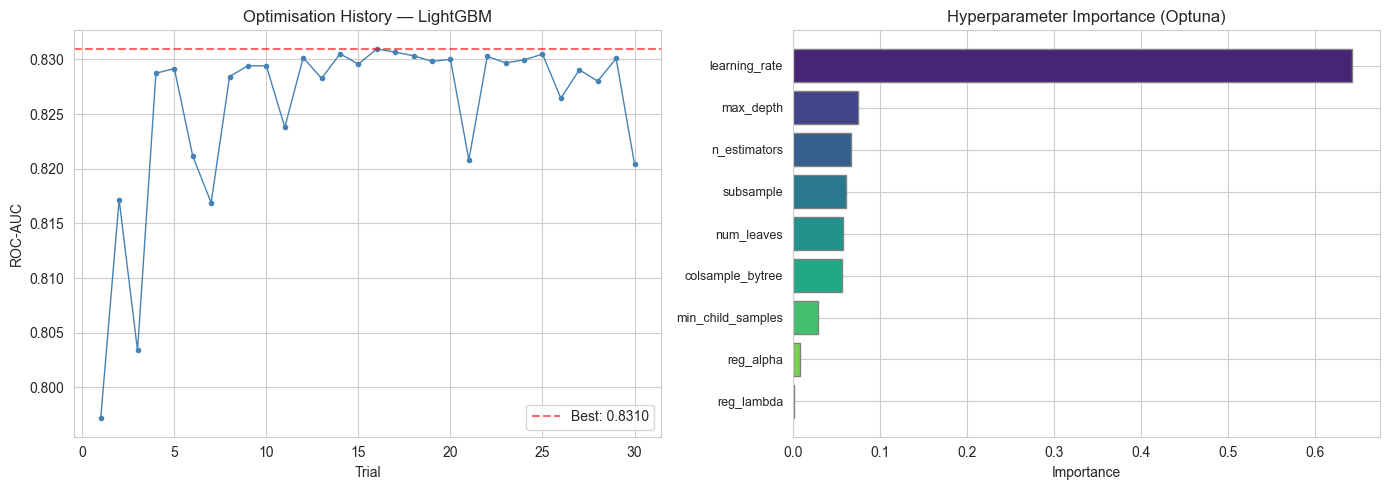

Best ROC-AUC: 0.8310


In [8]:
tune_result = tune_hyperparams(X_train_aug, y_train, model_name="LightGBM",
                                n_trials=30, n_folds=3, plot=True)
best_params = tune_result["params"]
print(f"Best ROC-AUC: {tune_result['best_score']:.4f}")

## Final Model & Predictions

FINAL MODEL

  Model:          LightGBM
  Samples:        145,241
  Positive:       8,846 (6.09%)
  Features:       38
  Calibration:    isotonic

  Params:
    n_estimators              = 850
    learning_rate             = 0.02373262658279773
    max_depth                 = 10
    num_leaves                = 54
    min_child_samples         = 52
    subsample                 = 0.5720733444180446
    colsample_bytree          = 0.5003628789248259
    reg_alpha                 = 1.9356277920826005e-08
    reg_lambda                = 3.2118600924893417

  Training LightGBM on full data...
  Calibrating (isotonic, 5-fold)...

  ── Metrics (train) ──
  ROC-AUC:   0.9222
  Gini:      0.8444
  F1:        0.5422
  Precision: 0.4859
  Recall:    0.6133
  Threshold: 0.1577

  Computing SHAP values...


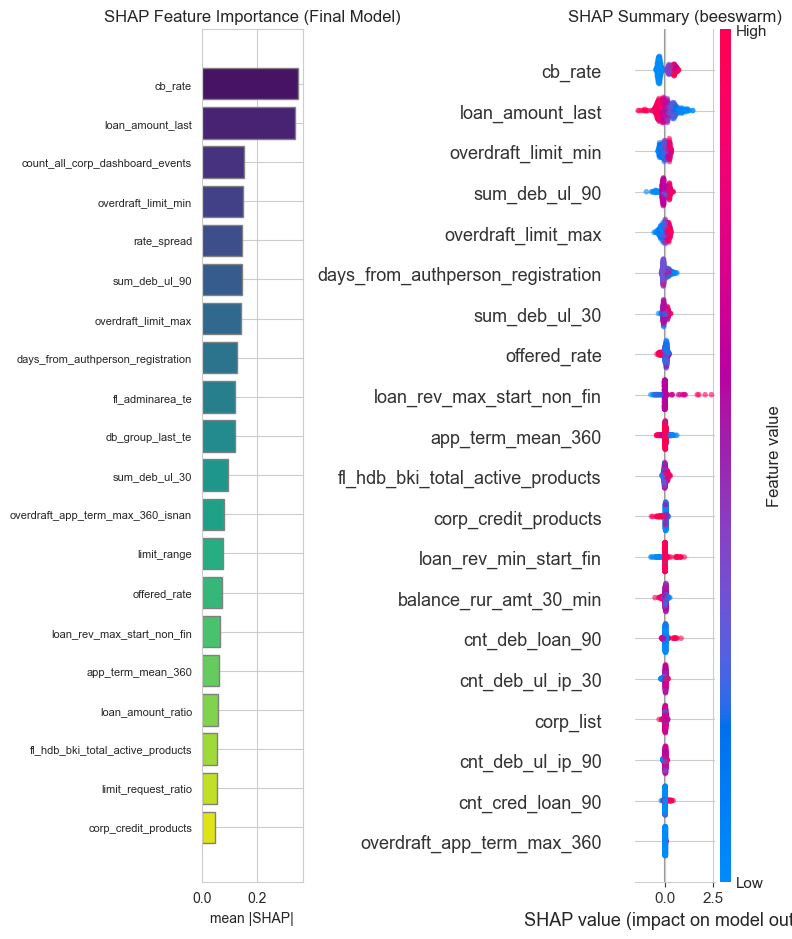

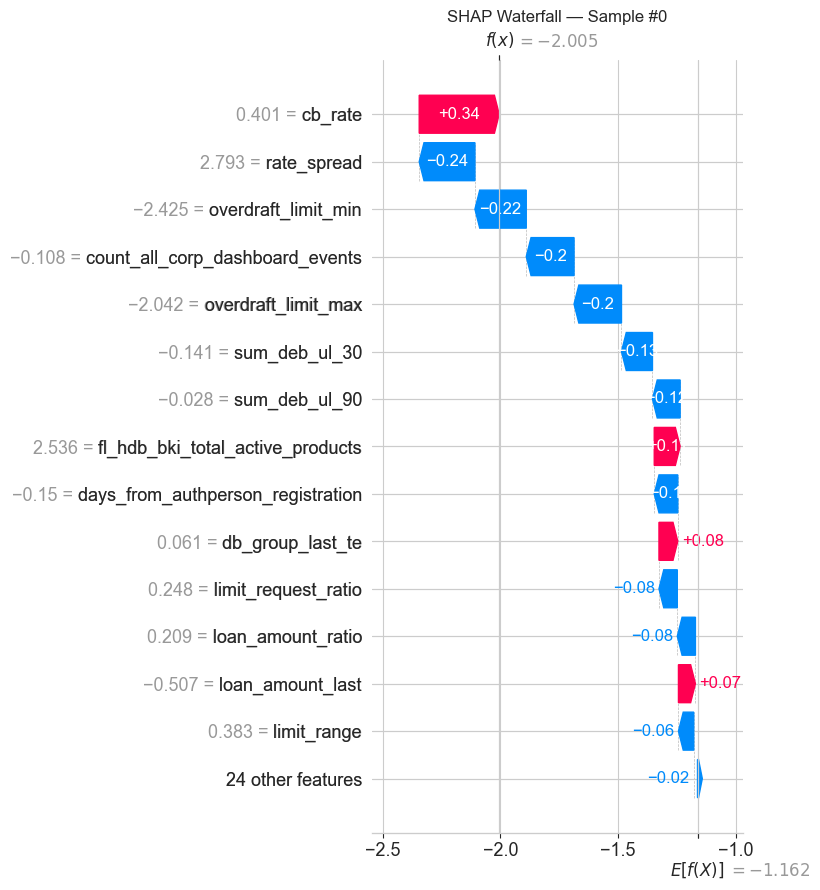

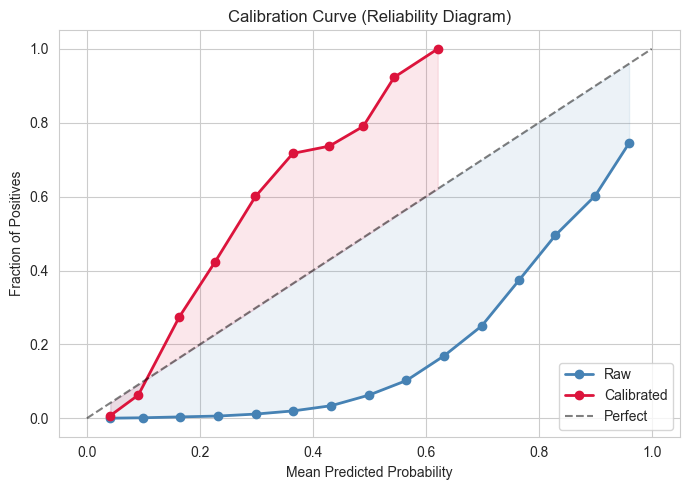


  Model saved: C:\Users\Lenovo\OneDrive\Sandbox\mfti\models\final_model.pkl

  Predictions: 36,311 samples
  Accepted:    4,249 (11.70%)
  Declined:    32,062 (88.30%)
  Threshold:   0.1577
  Predictions saved: C:\Users\Lenovo\OneDrive\Sandbox\mfti\outputs\predictions.csv


,front_id,predicted_proba,predicted_label
0,150378,0.122997,0
1,194170,0.058985,0
2,102106,0.044234,0
3,256199,0.072100,0
4,253573,0.072338,0
5,151278,0.056322,0
6,194374,0.046076,0
7,205556,0.133610,0
8,150772,0.073905,0
9,150514,0.086116,0


In [9]:
final = train_final_model(X_train_aug, y_train, best_params=best_params,
                           model_name="LightGBM", calibrate=True, plot=True)

preds = generate_predictions(
    final["model"], X_test_aug,
    front_ids=test["front_id"],
    calibrator=final["calibrator"],
    threshold=final["metrics"]["threshold"],
)
preds.head(10)